Praktikum 8 - Jaringan Syaraf Tiruan 3
Convolutional Neural Network (CNN) untuk Klasifikasi Gambar
Dataset: Rock Paper Scissors

Langkah 1: Import Library

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.21.0


Langkah 2: Persiapan Data menggunakan ImageDataGenerator

In [2]:
dataset_path = "./rockpaperscissors"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='training',
)

validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
)

print('Kelas yang terdeteksi:', train_generator.class_indices)
print(f'Jumlah data training  : {train_generator.samples}')
print(f'Jumlah data validasi  : {validation_generator.samples}')

Found 1751 images belonging to 3 classes.
Found 437 images belonging to 3 classes.
Kelas yang terdeteksi: {'paper': 0, 'rock': 1, 'scissors': 2}
Jumlah data training  : 1751
Jumlah data validasi  : 437


Langkah 3: Membangun Arsitektur Model CNN

In [3]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(512, activation='relu'),
    Dense(3, activation='softmax')
])

model.summary()

C:\Users\lenovo\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,035,203 (72.61 MB)

 Trainable params: 19,035,203 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

Langkah 4: Kompilasi Model

In [5]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print('Model berhasil dikompilasi!')

Model berhasil dikompilasi!


Langkah 5: Pelatihan Model (Model Fitting)

In [6]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.6528 - loss: 0.8137 - val_accuracy: 0.8650 - val_loss: 0.3961
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.9069 - loss: 0.2599 - val_accuracy: 0.9405 - val_loss: 0.1637
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.9652 - loss: 0.1098 - val_accuracy: 0.9519 - val_loss: 0.1461
Epoch 4/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.9840 - loss: 0.0519 - val_accuracy: 0.9634 - val_loss: 0.1110
Epoch 5/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.9931 - loss: 0.0263 - val_accuracy: 0.9680 - val_loss: 0.1126
Epoch 6/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.9977 - loss: 0.0141 - val_accuracy: 0.9611 - val_loss: 0.1381
Epoch 7/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.9949 - loss: 0.0208 - val_accuracy: 0.9245 - val_loss: 0.3252
Epoch 8/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.9943 - loss: 0.0262 - val_accuracy: 0.9680 - val_loss:

Langkah 6: Evaluasi Model

In [7]:
val_loss, val_acc = model.evaluate(validation_generator)
print(f'Validation loss: {val_loss}, Validation accuracy: {val_acc}')

14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 195ms/step - accuracy: 0.9748 - loss: 0.1412
Validation loss: 0.1411675065755844, Validation accuracy: 0.9748283624649048


Langkah 7: Prediksi pada Data Validasi

In [8]:
predictions = model.predict(validation_generator)
print(predictions)  # Output berupa probabilitas prediksi tiap kelas

14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 205ms/step
[[5.07300582e-12 3.49456388e-24 1.00000000e+00]
 [1.00000000e+00 9.89522131e-10 2.95697305e-14]
 [1.00000000e+00 7.80644704e-09 1.75009678e-08]
 ...
 [9.99987483e-01 3.33001959e-09 1.24683565e-05]
 [1.00000000e+00 3.78402379e-11 5.29588109e-11]
 [2.43635986e-06 9.99997497e-01 9.04818975e-09]]


Visualisasi Akurasi dan Loss Training

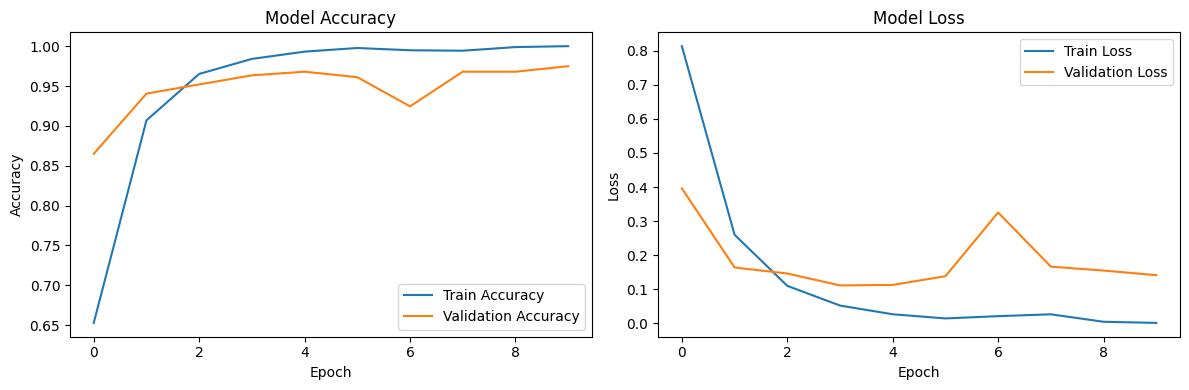

Plot disimpan sebagai training_history.png


In [9]:
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('training_history.png')
plt.show()
print('Plot disimpan sebagai training_history.png')